# Reglas de asociación aplicadas al burnout estudiantil

Este notebook identifica combinaciones de características que aparecen asociadas con
`burnout_cat=alto`. Las reglas de asociación permiten estudiar patrones compuestos,
por ejemplo:

```text
sleep_hours=bajo + stress_level=alto -> burnout_cat=alto
```

El análisis usa **support**, **confidence** y **lift** para evaluar la frecuencia y la
fuerza de cada patrón. Los resultados describen asociaciones observadas en el dataset:
no demuestran causalidad ni sustituyen un modelo predictivo.

## 1. Configuración y carga de datos

Se cargan las librerías necesarias y se busca `dataset_limpio.csv` desde ubicaciones
válidas tanto al ejecutar Jupyter desde la raíz del proyecto como desde `notebooks/`.
FP-Growth y la generación de reglas se implementan con `mlxtend`.

In [1]:
import os
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from mlxtend.frequent_patterns import association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")


def find_project_root():
    candidates = []
    if os.getenv("PROJECT_ROOT"):
        candidates.append(Path(os.environ["PROJECT_ROOT"]))
    if os.getenv("PWD"):
        candidates.append(Path(os.environ["PWD"]))
    candidates.extend([Path.cwd(), Path.cwd().parent])

    for candidate in candidates:
        dataset_path = candidate / "data" / "processed" / "dataset_limpio.csv"
        if dataset_path.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "No se encontró data/processed/dataset_limpio.csv. "
        "Ejecute el notebook desde la raíz del proyecto o defina PROJECT_ROOT."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_limpio.csv"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tablas"
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Dataset: {DATA_PATH}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset: /home/chop/Ufro/proyecto-ingenieria-datos/data/processed/dataset_limpio.csv
Dimensiones: 11,119 filas x 30 columnas


## 2. Revisión inicial

Antes de transformar las variables se revisan ejemplos, tipos de datos, columnas
disponibles y valores nulos. Esta verificación permite detectar cambios de esquema
antes de ejecutar el algoritmo.

In [2]:
display(df.head())

revision_columnas = pd.DataFrame(
    {
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "porcentaje_nulos": (df.isna().mean() * 100).round(2),
        "valores_unicos": df.nunique(dropna=True),
    }
)
display(revision_columnas)
print("Columnas disponibles:")
print(df.columns.tolist())

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,uses_ai_for_assignments,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,resume_confidence_score,interview_anxiety_score,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,Never,1,1,3,2,6,2,11,5,2,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,Rarely,3,7,5,3,8,2,19,4,7,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,Sometimes,4,7,6,3,6,1,15,3,6,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,Frequently,4,4,3,4,7,3,8,5,4,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,Sometimes,4,10,8,5,3,3,5,4,9,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


,tipo,nulos,porcentaje_nulos,valores_unicos
student_id,str,0,0.0,11119
age,int64,0,0.0,11
gender,str,0,0.0,3
degree_type,str,0,0.0,4
stream,str,0,0.0,4
year_of_study,int64,0,0.0,4
college_tier,str,0,0.0,3
urban_or_rural,str,0,0.0,2
daily_ai_tool_usage_hrs,float64,0,0.0,79
primary_ai_tools_used,str,0,0.0,5


Columnas disponibles:
['student_id', 'age', 'gender', 'degree_type', 'stream', 'year_of_study', 'college_tier', 'urban_or_rural', 'daily_ai_tool_usage_hrs', 'primary_ai_tools_used', 'uses_ai_for_assignments', 'ai_replaces_own_thinking_score', 'ai_dependency_score', 'placement_anxiety_score', 'fear_of_job_loss_to_ai', 'career_clarity_score', 'internship_experience', 'weekly_job_application_count', 'resume_confidence_score', 'interview_anxiety_score', 'daily_study_hours', 'self_learning_hours_per_week', 'skill_development_courses_taken', 'social_media_hrs_per_day', 'sleep_hours', 'stress_level', 'burnout_score', 'motivation_score', 'seeks_career_counseling', 'overall_career_readiness_score']


### Distribución original de `burnout_score`

`burnout_score` es numérica. Para utilizarla como consecuente de una regla debe
convertirse en una categoría que pueda representarse como un ítem.

,burnout_score,frecuencia
0,1,269
1,2,464
2,3,1025
3,4,1474
4,5,2018
5,6,2051
6,7,1712
7,8,1125
8,9,629
9,10,352


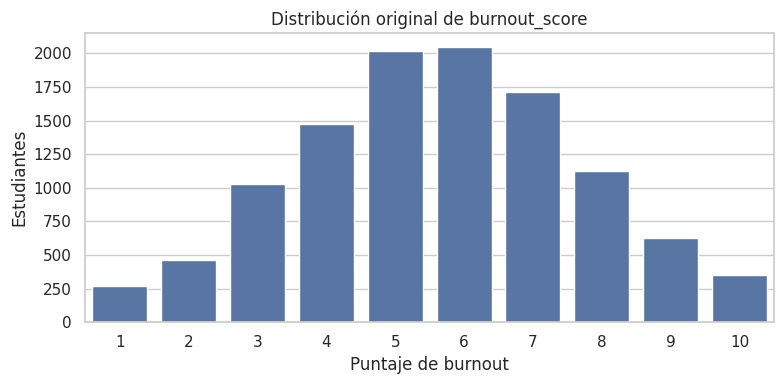

In [3]:
burnout_original = (
    df["burnout_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("burnout_score")
    .reset_index(name="frecuencia")
)
display(burnout_original)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="burnout_score", color="#4C72B0")
plt.title("Distribución original de burnout_score")
plt.xlabel("Puntaje de burnout")
plt.ylabel("Estudiantes")
plt.tight_layout()
plt.show()

## 3. Variable objetivo: `burnout_cat`

Se aplican los cortes definidos en la metodología:

- **bajo:** `burnout_score <= 3`
- **medio:** `4 <= burnout_score <= 6`
- **alto:** `burnout_score >= 7`

El análisis posterior conservará únicamente reglas cuyo consecuente sea exactamente
`burnout_cat=alto`.

,burnout_cat,frecuencia,porcentaje
0,bajo,1758,15.81
1,medio,5543,49.85
2,alto,3818,34.34


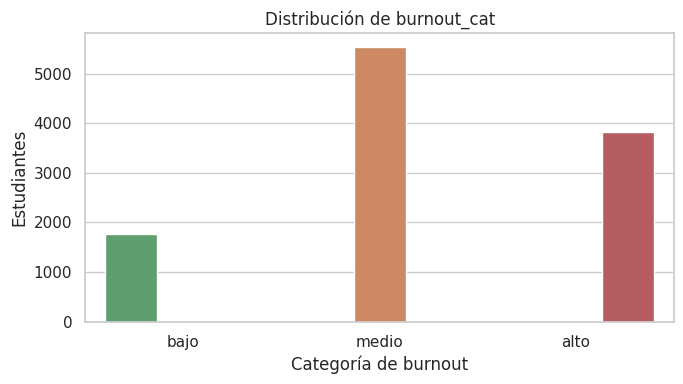

In [4]:
df_analysis = df.copy()
df_analysis["burnout_cat"] = pd.cut(
    pd.to_numeric(df_analysis["burnout_score"], errors="coerce"),
    bins=[-np.inf, 3, 6, np.inf],
    labels=["bajo", "medio", "alto"],
)

burnout_distribution = (
    df_analysis["burnout_cat"]
    .value_counts(sort=False)
    .rename_axis("burnout_cat")
    .reset_index(name="frecuencia")
)
burnout_distribution["porcentaje"] = (
    burnout_distribution["frecuencia"] / len(df_analysis) * 100
).round(2)
display(burnout_distribution)

plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df_analysis,
    x="burnout_cat",
    order=["bajo", "medio", "alto"],
    hue="burnout_cat",
    palette={"bajo": "#55A868", "medio": "#DD8452", "alto": "#C44E52"},
    legend=False,
)
ax.set_title("Distribución de burnout_cat")
ax.set_xlabel("Categoría de burnout")
ax.set_ylabel("Estudiantes")
plt.tight_layout()
plt.show()

## 4. Selección justificada de variables

Se incluyen tres bloques conceptuales: variables subjetivas, variables asociadas al
uso de IA y variables conductuales o contextuales. `student_id` queda excluida por
ser un identificador. Si una columna esperada no existe, se informa y el análisis
continúa con las variables disponibles.

In [5]:
variable_groups = {
    "Subjetivas": [
        "stress_level",
        "motivation_score",
        "placement_anxiety_score",
        "interview_anxiety_score",
        "career_clarity_score",
        "resume_confidence_score",
    ],
    "Uso de IA": [
        "daily_ai_tool_usage_hrs",
        "uses_ai_for_assignments",
        "ai_dependency_score",
        "ai_replaces_own_thinking_score",
        "fear_of_job_loss_to_ai",
    ],
    "Conductuales y contextuales": [
        "sleep_hours",
        "daily_study_hours",
        "social_media_hrs_per_day",
        "weekly_job_application_count",
        "internship_experience",
        "seeks_career_counseling",
        "college_tier",
        "stream",
        "degree_type",
    ],
}

requested_variables = [
    variable
    for variables in variable_groups.values()
    for variable in variables
]
available_variables = [
    variable for variable in requested_variables if variable in df_analysis.columns
]
missing_variables = [
    variable for variable in requested_variables if variable not in df_analysis.columns
]

selection_summary = pd.DataFrame(
    [
        {
            "grupo": group,
            "solicitadas": len(variables),
            "disponibles": sum(v in available_variables for v in variables),
            "variables": ", ".join(v for v in variables if v in available_variables),
        }
        for group, variables in variable_groups.items()
    ]
)
display(selection_summary)

if missing_variables:
    warnings.warn(
        "Se ignorarán columnas no disponibles: " + ", ".join(missing_variables)
    )
else:
    print("Todas las variables solicitadas están disponibles.")

,grupo,solicitadas,disponibles,variables
0,Subjetivas,6,6,"stress_level, motivation_score, placement_anxiety_score, interview_anxiety_score, career_clarity_score, resume_confi..."
1,Uso de IA,5,5,"daily_ai_tool_usage_hrs, uses_ai_for_assignments, ai_dependency_score, ai_replaces_own_thinking_score, fear_of_job_l..."
2,Conductuales y contextuales,9,9,"sleep_hours, daily_study_hours, social_media_hrs_per_day, weekly_job_application_count, internship_experience, seeks..."


Todas las variables solicitadas están disponibles.


## 5. Discretización

Las variables numéricas se convierten a categorías interpretables mediante cortes
definidos a priori. Las variables categóricas conservan su significado, pero sus
etiquetas se normalizan para formar ítems con el formato `variable=valor`.

Usar cortes explícitos favorece la interpretación, aunque también implica que los
resultados dependen de estas decisiones metodológicas.

In [6]:
def scale_1_to_10(series):
    values = pd.to_numeric(series, errors="coerce")
    return pd.cut(
        values,
        bins=[-np.inf, 3, 6, np.inf],
        labels=["bajo", "medio", "alto"],
    )


def scale_1_to_5(series):
    values = pd.to_numeric(series, errors="coerce")
    return pd.cut(
        values,
        bins=[-np.inf, 2, 3, np.inf],
        labels=["bajo", "medio", "alto"],
    )


def categorize_with_conditions(series, conditions, labels):
    values = pd.to_numeric(series, errors="coerce")
    result = np.select(conditions(values), labels, default="sin_dato")
    return pd.Series(result, index=series.index, dtype="object")


def clean_category(series):
    cleaned = (
        series.astype("string")
        .fillna("sin_dato")
        .str.strip()
        .str.replace(r"\s+", "_", regex=True)
        .str.lower()
    )
    return cleaned


def discretize_variables(data, variables):
    discretized = pd.DataFrame(index=data.index)

    scale_10_variables = {
        "stress_level",
        "motivation_score",
        "placement_anxiety_score",
        "interview_anxiety_score",
        "career_clarity_score",
        "resume_confidence_score",
        "ai_dependency_score",
        "ai_replaces_own_thinking_score",
    }

    for variable in variables:
        if variable in scale_10_variables:
            discretized[variable] = scale_1_to_10(data[variable]).astype("string")
        elif variable == "fear_of_job_loss_to_ai":
            discretized[variable] = scale_1_to_5(data[variable]).astype("string")
        elif variable == "sleep_hours":
            discretized[variable] = categorize_with_conditions(
                data[variable],
                lambda x: [x < 6, (x >= 6) & (x <= 8), x > 8],
                ["bajo", "medio", "alto"],
            )
        elif variable == "daily_ai_tool_usage_hrs":
            discretized[variable] = categorize_with_conditions(
                data[variable],
                lambda x: [x < 1, (x >= 1) & (x <= 3), x > 3],
                ["bajo", "medio", "alto"],
            )
        elif variable == "daily_study_hours":
            discretized[variable] = categorize_with_conditions(
                data[variable],
                lambda x: [x < 2, (x >= 2) & (x <= 5), x > 5],
                ["bajo", "medio", "alto"],
            )
        elif variable == "social_media_hrs_per_day":
            discretized[variable] = categorize_with_conditions(
                data[variable],
                lambda x: [x < 2, (x >= 2) & (x <= 4), x > 4],
                ["bajo", "medio", "alto"],
            )
        elif variable == "weekly_job_application_count":
            discretized[variable] = categorize_with_conditions(
                data[variable],
                lambda x: [x <= 1, (x >= 2) & (x <= 5), x > 5],
                ["bajo", "medio", "alto"],
            )
        elif variable == "seeks_career_counseling":
            numeric = pd.to_numeric(data[variable], errors="coerce")
            discretized[variable] = numeric.map({0: "no", 1: "si"}).fillna("sin_dato")
        else:
            discretized[variable] = clean_category(data[variable])

    discretized["burnout_cat"] = data["burnout_cat"].astype("string")
    return discretized.fillna("sin_dato")


discretized = discretize_variables(df_analysis, available_variables)
display(discretized.head())

,stress_level,motivation_score,placement_anxiety_score,interview_anxiety_score,career_clarity_score,resume_confidence_score,daily_ai_tool_usage_hrs,uses_ai_for_assignments,ai_dependency_score,ai_replaces_own_thinking_score,fear_of_job_loss_to_ai,sleep_hours,daily_study_hours,social_media_hrs_per_day,weekly_job_application_count,internship_experience,seeks_career_counseling,college_tier,stream,degree_type,burnout_cat
0,bajo,medio,bajo,bajo,medio,medio,bajo,never,bajo,bajo,bajo,alto,medio,bajo,alto,2,no,tier_3,engineering_(non-cs),b.tech/b.e.,bajo
1,medio,bajo,medio,alto,alto,medio,medio,rarely,alto,bajo,medio,alto,medio,alto,alto,2,no,tier_3,engineering_(non-cs),b.tech/b.e.,medio
2,medio,bajo,medio,medio,medio,bajo,alto,sometimes,alto,medio,medio,medio,medio,medio,alto,1,si,tier_3,cs/it,mba,alto
3,medio,medio,bajo,medio,alto,medio,alto,frequently,medio,medio,alto,medio,alto,medio,alto,3,no,tier_1,cs/it,b.tech/b.e.,medio
4,bajo,medio,alto,alto,bajo,medio,alto,sometimes,alto,medio,alto,medio,medio,bajo,medio,3,no,tier_1,cs/it,mba,medio


### Validación de las categorías

Se revisa cuántos casos quedaron en cada categoría. Una categoría muy pequeña puede
producir reglas inestables o quedar fuera por el umbral de soporte.

In [7]:
category_counts = pd.concat(
    {
        column: discretized[column].value_counts(dropna=False)
        for column in discretized.columns
    },
    names=["variable", "categoria"],
).rename("frecuencia").reset_index()
category_counts["porcentaje_variable"] = (
    category_counts["frecuencia"]
    / category_counts.groupby("variable")["frecuencia"].transform("sum")
    * 100
).round(2)
display(category_counts)

,variable,categoria,frecuencia,porcentaje_variable
0,stress_level,medio,6580,59.18
1,stress_level,bajo,2584,23.24
2,stress_level,alto,1955,17.58
3,motivation_score,medio,5096,45.83
4,motivation_score,bajo,4318,38.83
...,...,...,...,...
61,degree_type,m.tech/m.sc,1703,15.32
62,degree_type,mba,1069,9.61
63,burnout_cat,medio,5543,49.85
64,burnout_cat,alto,3818,34.34


## 6. Construcción de transacciones

Cada estudiante se representa como una transacción con un ítem por variable. Luego
se aplica one-hot encoding booleano: cada columna indica si el ítem está presente en
la transacción.

In [8]:
item_data = discretized.copy()
for column in item_data.columns:
    item_data[column] = column + "=" + item_data[column].astype(str)

transactions = item_data.apply(lambda row: row.tolist(), axis=1)
encoder = TransactionEncoder()
encoded_transactions = encoder.fit(transactions).transform(transactions)
transaction_matrix = pd.DataFrame(
    encoded_transactions,
    columns=encoder.columns_,
    index=item_data.index,
)

print("Ejemplos de transacciones:")
for transaction in transactions.head(3):
    print(transaction)

print(
    f"\nMatriz one-hot: {transaction_matrix.shape[0]:,} transacciones "
    f"x {transaction_matrix.shape[1]} ítems"
)
display(transaction_matrix.head())

Ejemplos de transacciones:
['stress_level=bajo', 'motivation_score=medio', 'placement_anxiety_score=bajo', 'interview_anxiety_score=bajo', 'career_clarity_score=medio', 'resume_confidence_score=medio', 'daily_ai_tool_usage_hrs=bajo', 'uses_ai_for_assignments=never', 'ai_dependency_score=bajo', 'ai_replaces_own_thinking_score=bajo', 'fear_of_job_loss_to_ai=bajo', 'sleep_hours=alto', 'daily_study_hours=medio', 'social_media_hrs_per_day=bajo', 'weekly_job_application_count=alto', 'internship_experience=2', 'seeks_career_counseling=no', 'college_tier=tier_3', 'stream=engineering_(non-cs)', 'degree_type=b.tech/b.e.', 'burnout_cat=bajo']
['stress_level=medio', 'motivation_score=bajo', 'placement_anxiety_score=medio', 'interview_anxiety_score=alto', 'career_clarity_score=alto', 'resume_confidence_score=medio', 'daily_ai_tool_usage_hrs=medio', 'uses_ai_for_assignments=rarely', 'ai_dependency_score=alto', 'ai_replaces_own_thinking_score=bajo', 'fear_of_job_loss_to_ai=medio', 'sleep_hours=alto',

,ai_dependency_score=alto,ai_dependency_score=bajo,ai_dependency_score=medio,ai_replaces_own_thinking_score=bajo,ai_replaces_own_thinking_score=medio,burnout_cat=alto,burnout_cat=bajo,burnout_cat=medio,career_clarity_score=alto,career_clarity_score=bajo,career_clarity_score=medio,college_tier=tier_1,college_tier=tier_2,college_tier=tier_3,daily_ai_tool_usage_hrs=alto,...,stream=arts/sciences,stream=commerce/management,stream=cs/it,stream=engineering_(non-cs),stress_level=alto,stress_level=bajo,stress_level=medio,uses_ai_for_assignments=always,uses_ai_for_assignments=frequently,uses_ai_for_assignments=never,uses_ai_for_assignments=rarely,uses_ai_for_assignments=sometimes,weekly_job_application_count=alto,weekly_job_application_count=bajo,weekly_job_application_count=medio
0,False,True,False,True,False,False,True,False,False,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False
1,True,False,False,True,False,False,False,True,True,False,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False
2,True,False,False,False,True,True,False,False,False,False,True,False,False,True,True,...,False,False,True,False,False,False,True,False,False,False,False,True,True,False,False
3,False,False,True,False,True,False,False,True,True,False,False,True,False,False,True,...,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False
4,True,False,False,False,True,False,False,True,False,True,False,True,False,False,True,...,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True


## 7. Algoritmo y generación de itemsets frecuentes

Se utiliza **FP-Growth** como algoritmo principal. Apriori es sencillo de explicar,
pero genera candidatos explícitamente y puede crecer con rapidez; FP-Growth comprime
las transacciones y evita esa enumeración. Eclat no se prioriza porque su
representación vertical puede consumir más memoria y no es necesaria aquí.

Se usa `min_support=0.03`: un itemset debe aparecer en al menos 3% de los estudiantes.
Además, `max_len=4` permite reglas con un consecuente y hasta tres antecedentes, lo
que mantiene la interpretación manejable. Apriori puede reemplazar a FP-Growth sin
cambiar el resto del flujo si fuera necesario.

In [9]:
MIN_SUPPORT = 0.03
MAX_ITEMSET_LENGTH = 4

frequent_itemsets = fpgrowth(
    transaction_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_LENGTH,
).sort_values("support", ascending=False, ignore_index=True)

print(f"Itemsets frecuentes encontrados: {len(frequent_itemsets):,}")
itemsets_display = frequent_itemsets.head(20).copy()
itemsets_display["itemsets"] = itemsets_display["itemsets"].map(
    lambda items: " + ".join(sorted(items))
)
display(itemsets_display)

Itemsets frecuentes encontrados: 63,725


,support,itemsets
0,0.772102,weekly_job_application_count=alto
1,0.708787,seeks_career_counseling=no
2,0.702311,sleep_hours=medio
3,0.591780,stress_level=medio
4,0.584855,fear_of_job_loss_to_ai=alto
5,0.566238,ai_replaces_own_thinking_score=bajo
6,0.543844,sleep_hours=medio + weekly_job_application_count=alto
7,0.542495,resume_confidence_score=bajo
8,0.529904,daily_study_hours=medio
9,0.527475,seeks_career_counseling=no + weekly_job_application_count=alto


## 8. Reglas orientadas a burnout alto

El **support** mide la proporción de estudiantes que cumple antecedente y consecuente.
La **confidence** mide la proporción con burnout alto entre quienes cumplen el
antecedente. El **lift** compara esa probabilidad con la frecuencia base de burnout
alto; valores mayores que 1 indican asociación positiva.

In [10]:
TARGET_ITEM = "burnout_cat=alto"


def format_itemset(items):
    return " + ".join(sorted(items))


all_rules = association_rules(
    frequent_itemsets,
    metric="support",
    min_threshold=MIN_SUPPORT,
)

target_rules = all_rules[
    all_rules["consequents"].eq(frozenset({TARGET_ITEM}))
].copy()
target_rules["n_antecedentes"] = target_rules["antecedents"].map(len)
target_rules = target_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False,
    ignore_index=True,
)

print(f"Reglas generales: {len(all_rules):,}")
print(f"Reglas con consecuente {TARGET_ITEM}: {len(target_rules):,}")

target_rules_display = target_rules.head(15).copy()
target_rules_display["antecedente"] = target_rules_display["antecedents"].map(
    format_itemset
)
display(
    target_rules_display[
        ["antecedente", "support", "confidence", "lift", "n_antecedentes"]
    ].round(3)
)

Reglas generales: 753,466
Reglas con consecuente burnout_cat=alto: 4,286


,antecedente,support,confidence,lift,n_antecedentes
0,ai_dependency_score=alto + motivation_score=bajo + stress_level=alto,0.033,0.951,2.771,3
1,daily_ai_tool_usage_hrs=alto + motivation_score=bajo + stress_level=alto,0.035,0.923,2.687,3
2,ai_replaces_own_thinking_score=medio + seeks_career_counseling=si + stress_level=alto,0.038,0.913,2.658,3
3,motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,0.048,0.911,2.652,3
4,daily_ai_tool_usage_hrs=alto + seeks_career_counseling=si + stress_level=alto,0.032,0.907,2.642,3
5,ai_replaces_own_thinking_score=medio + motivation_score=bajo + stress_level=alto,0.045,0.890,2.593,3
6,ai_dependency_score=alto + ai_replaces_own_thinking_score=medio + stress_level=alto,0.038,0.887,2.583,3
7,ai_dependency_score=alto + placement_anxiety_score=alto + stress_level=alto,0.040,0.882,2.568,3
8,ai_dependency_score=alto + stress_level=alto + weekly_job_application_count=alto,0.042,0.880,2.564,3
9,ai_dependency_score=alto + stream=cs/it + stress_level=alto,0.035,0.880,2.564,3


## 9. Filtros de calidad

Se consideran relevantes las reglas que cumplen:

- `support >= 0.03`
- `confidence >= 0.50`
- `lift > 1.30`
- máximo 3 antecedentes

Un lift cercano a 1 aporta poca evidencia de asociación. Un lift superior a 1.3 es
un criterio práctico para priorizar patrones, pero no compensa un soporte muy bajo.

In [11]:
MIN_CONFIDENCE = 0.50
MIN_LIFT = 1.30
MAX_ANTECEDENTS = 3

relevant_rules = target_rules[
    (target_rules["support"] >= MIN_SUPPORT)
    & (target_rules["confidence"] >= MIN_CONFIDENCE)
    & (target_rules["lift"] > MIN_LIFT)
    & (target_rules["n_antecedentes"] <= MAX_ANTECEDENTS)
].copy()

relevant_rules["antecedente"] = relevant_rules["antecedents"].map(format_itemset)
relevant_rules["consecuente"] = TARGET_ITEM

print(f"Reglas relevantes después de filtrar: {len(relevant_rules):,}")
best_rules_table = relevant_rules[
    [
        "antecedente",
        "consecuente",
        "support",
        "confidence",
        "lift",
        "n_antecedentes",
    ]
].head(20)
display(best_rules_table.round(3))

Reglas relevantes después de filtrar: 1,576


,antecedente,consecuente,support,confidence,lift,n_antecedentes
0,ai_dependency_score=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.033,0.951,2.771,3
1,daily_ai_tool_usage_hrs=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.035,0.923,2.687,3
2,ai_replaces_own_thinking_score=medio + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.038,0.913,2.658,3
3,motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.048,0.911,2.652,3
4,daily_ai_tool_usage_hrs=alto + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.032,0.907,2.642,3
5,ai_replaces_own_thinking_score=medio + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.045,0.890,2.593,3
6,ai_dependency_score=alto + ai_replaces_own_thinking_score=medio + stress_level=alto,burnout_cat=alto,0.038,0.887,2.583,3
7,ai_dependency_score=alto + placement_anxiety_score=alto + stress_level=alto,burnout_cat=alto,0.040,0.882,2.568,3
8,ai_dependency_score=alto + stress_level=alto + weekly_job_application_count=alto,burnout_cat=alto,0.042,0.880,2.564,3
9,ai_dependency_score=alto + stream=cs/it + stress_level=alto,burnout_cat=alto,0.035,0.880,2.564,3


## 9.1 Priorización de reglas relevantes

Aunque el filtro inicial permite identificar reglas asociadas a `burnout_cat=alto`, el algoritmo puede generar una gran cantidad de reglas que cumplen los umbrales mínimos. Esto no significa que todas sean igualmente útiles para la interpretación. Por esta razón, se agrega una etapa de priorización cuyo objetivo es conservar reglas con mejor calidad estadística e interpretabilidad.

Se distinguen dos niveles:

1. **Reglas exploratorias:** tienen como consecuente `burnout_cat=alto`, cumplen los umbrales iniciales de support, confidence y lift, y permiten revisar patrones amplios.
2. **Reglas priorizadas:** forman un subconjunto más estricto, con mayor confianza, lift alto y pocos antecedentes, adecuado para la conclusión y presentación de resultados.

In [12]:
# Priorización de reglas relevantes
# Se parte desde relevant_rules, que ya cumple los filtros exploratorios.
if "n_antecedentes" not in relevant_rules.columns:
    relevant_rules["n_antecedentes"] = relevant_rules["antecedents"].apply(len)

priority_rules = relevant_rules[
    (relevant_rules["support"] >= 0.03)
    & (relevant_rules["confidence"] >= 0.70)
    & (relevant_rules["lift"] >= 2.00)
    & (relevant_rules["n_antecedentes"].between(2, 3))
].copy()

priority_rules = priority_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False,
    ignore_index=True,
)

print(f"Reglas relevantes iniciales: {len(relevant_rules):,}")
print(f"Reglas priorizadas: {len(priority_rules):,}")

display(
    priority_rules[
        ["antecedente", "consecuente", "support", "confidence", "lift", "n_antecedentes"]
    ].head(20).round(3)
)

Reglas relevantes iniciales: 1,576
Reglas priorizadas: 282


,antecedente,consecuente,support,confidence,lift,n_antecedentes
0,ai_dependency_score=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.033,0.951,2.771,3
1,daily_ai_tool_usage_hrs=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.035,0.923,2.687,3
2,ai_replaces_own_thinking_score=medio + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.038,0.913,2.658,3
3,motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.048,0.911,2.652,3
4,daily_ai_tool_usage_hrs=alto + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.032,0.907,2.642,3
5,ai_replaces_own_thinking_score=medio + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.045,0.890,2.593,3
6,ai_dependency_score=alto + ai_replaces_own_thinking_score=medio + stress_level=alto,burnout_cat=alto,0.038,0.887,2.583,3
7,ai_dependency_score=alto + placement_anxiety_score=alto + stress_level=alto,burnout_cat=alto,0.040,0.882,2.568,3
8,ai_dependency_score=alto + stress_level=alto + weekly_job_application_count=alto,burnout_cat=alto,0.042,0.880,2.564,3
9,ai_dependency_score=alto + stream=cs/it + stress_level=alto,burnout_cat=alto,0.035,0.880,2.564,3


### Interpretación del filtro de priorización

Los criterios usados para priorizar reglas son:

| Criterio | Valor usado | Justificación |
|---|---:|---|
| Soporte mínimo | `0.03` | La regla debe aparecer en una proporción mínima del dataset. |
| Confianza mínima | `0.70` | Al menos 70% de los casos que cumplen el antecedente presentan burnout alto. |
| Lift mínimo | `2.00` | La regla al menos duplica la probabilidad base de observar burnout alto. |
| Número de antecedentes | `2 a 3` | Se priorizan reglas compuestas, pero interpretables. |

Este filtro no reemplaza el análisis exploratorio anterior. Su función es construir una conclusión más clara a partir de un subconjunto exigente y manejable.

## 9.2 Reducción de reglas redundantes

Muchas reglas pueden ser variaciones de una misma idea. Por ejemplo:

```text
stress_level=alto + motivation_score=bajo -> burnout_cat=alto
stress_level=alto + motivation_score=bajo + sleep_hours=medio -> burnout_cat=alto
```

Ambas pueden entregar una interpretación similar. Para evitar conclusiones repetidas, se conserva una regla más compleja solo cuando aporta una mejora suficiente en lift respecto de una regla ya seleccionada con antecedentes contenidos en ella.

In [13]:
def remove_redundant_rules(rules_df, lift_improvement_threshold=1.05):
    """Reduce reglas anidadas que no mejoran suficientemente el lift."""
    if rules_df.empty:
        return rules_df.copy()

    rules = rules_df.copy()
    rules["antecedents_set"] = rules["antecedents"].apply(set)
    selected_rules = []

    # Las reglas simples se evalúan primero para que actúen como referencia.
    ordered_rules = rules.sort_values(
        ["n_antecedentes", "lift", "confidence", "support"],
        ascending=[True, False, False, False],
    )

    for _, rule in ordered_rules.iterrows():
        current_antecedents = rule["antecedents_set"]
        is_redundant = False

        for selected in selected_rules:
            selected_antecedents = selected["antecedents_set"]
            if selected_antecedents.issubset(current_antecedents):
                if rule["lift"] <= selected["lift"] * lift_improvement_threshold:
                    is_redundant = True
                    break

        if not is_redundant:
            selected_rules.append(rule)

    non_redundant = pd.DataFrame(selected_rules)
    if "antecedents_set" in non_redundant.columns:
        non_redundant = non_redundant.drop(columns=["antecedents_set"])

    return non_redundant.sort_values(
        ["lift", "confidence", "support"],
        ascending=False,
        ignore_index=True,
    )


non_redundant_rules = remove_redundant_rules(priority_rules)

print(f"Reglas priorizadas antes de reducir redundancia: {len(priority_rules):,}")
print(f"Reglas no redundantes: {len(non_redundant_rules):,}")

display(
    non_redundant_rules[
        ["antecedente", "consecuente", "support", "confidence", "lift", "n_antecedentes"]
    ].head(20).round(3)
)

Reglas priorizadas antes de reducir redundancia: 282
Reglas no redundantes: 65


,antecedente,consecuente,support,confidence,lift,n_antecedentes
0,ai_dependency_score=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.033,0.951,2.771,3
1,daily_ai_tool_usage_hrs=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.035,0.923,2.687,3
2,ai_replaces_own_thinking_score=medio + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.038,0.913,2.658,3
3,motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.048,0.911,2.652,3
4,daily_ai_tool_usage_hrs=alto + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.032,0.907,2.642,3
5,ai_dependency_score=alto + stress_level=alto,burnout_cat=alto,0.048,0.871,2.537,2
6,motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.078,0.855,2.491,2
7,seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.074,0.837,2.436,2
8,ai_dependency_score=alto + motivation_score=bajo + seeks_career_counseling=si,burnout_cat=alto,0.054,0.831,2.420,3
9,ai_replaces_own_thinking_score=medio + stress_level=alto,burnout_cat=alto,0.062,0.824,2.401,2


## 9.3 Mejor regla por grupo de variables

Para evitar que muchas reglas similares dominen la interpretación, se agrupan según las variables presentes en el antecedente, ignorando el valor específico de cada categoría. Luego se selecciona la mejor regla de cada grupo según lift, confidence y support.

Por ejemplo, `stress_level=alto + motivation_score=bajo` y `stress_level=alto + motivation_score=medio` pertenecen al grupo conceptual `stress_level + motivation_score`.

In [14]:
def extract_variable_group(antecedents):
    """Extrae y ordena los nombres de variables presentes en un antecedente."""
    variables = [str(item).split("=", 1)[0] for item in antecedents]
    return tuple(sorted(set(variables)))


rules_for_grouping = non_redundant_rules.copy()
rules_for_grouping["grupo_variables"] = rules_for_grouping["antecedents"].apply(
    extract_variable_group
)

best_by_group = (
    rules_for_grouping
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .groupby("grupo_variables", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

print(f"Grupos de variables representados: {best_by_group['grupo_variables'].nunique():,}")

display(
    best_by_group[
        ["grupo_variables", "antecedente", "consecuente", "support", "confidence", "lift"]
    ].head(20).round(3)
)

Grupos de variables representados: 61


,grupo_variables,antecedente,consecuente,support,confidence,lift
0,"(ai_dependency_score, motivation_score, stress_level)",ai_dependency_score=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.033,0.951,2.771
1,"(daily_ai_tool_usage_hrs, motivation_score, stress_level)",daily_ai_tool_usage_hrs=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.035,0.923,2.687
2,"(ai_replaces_own_thinking_score, seeks_career_counseling, stress_level)",ai_replaces_own_thinking_score=medio + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.038,0.913,2.658
3,"(motivation_score, seeks_career_counseling, stress_level)",motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.048,0.911,2.652
4,"(daily_ai_tool_usage_hrs, seeks_career_counseling, stress_level)",daily_ai_tool_usage_hrs=alto + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.032,0.907,2.642
5,"(ai_dependency_score, stress_level)",ai_dependency_score=alto + stress_level=alto,burnout_cat=alto,0.048,0.871,2.537
6,"(motivation_score, stress_level)",motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.078,0.855,2.491
7,"(seeks_career_counseling, stress_level)",seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.074,0.837,2.436
8,"(ai_dependency_score, motivation_score, seeks_career_counseling)",ai_dependency_score=alto + motivation_score=bajo + seeks_career_counseling=si,burnout_cat=alto,0.054,0.831,2.420
9,"(ai_replaces_own_thinking_score, stress_level)",ai_replaces_own_thinking_score=medio + stress_level=alto,burnout_cat=alto,0.062,0.824,2.401


## 9.4 Ranking balanceado de reglas finales

Ordenar solo por lift puede priorizar reglas muy específicas, mientras que ordenar solo por confidence puede ignorar el soporte. Por eso se construye un ranking balanceado:

```text
score = lift * confidence * sqrt(support)
```

Este puntaje favorece reglas con asociación fuerte, alta confianza y presencia suficiente en el dataset. Se conservan como máximo diez reglas para la interpretación final.

In [15]:
rules_ranked = best_by_group.copy()
rules_ranked["score"] = (
    rules_ranked["lift"]
    * rules_ranked["confidence"]
    * np.sqrt(rules_ranked["support"])
)

final_rules = rules_ranked.sort_values(
    ["score", "lift", "confidence", "support"],
    ascending=False,
).head(10).reset_index(drop=True)

display(
    final_rules[
        ["antecedente", "consecuente", "support", "confidence", "lift", "score"]
    ].round(3)
)

,antecedente,consecuente,support,confidence,lift,score
0,motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.078,0.855,2.491,0.594
1,seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.074,0.837,2.436,0.553
2,motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.048,0.911,2.652,0.527
3,motivation_score=bajo + seeks_career_counseling=si,burnout_cat=alto,0.119,0.724,2.109,0.526
4,fear_of_job_loss_to_ai=alto + stress_level=alto,burnout_cat=alto,0.106,0.742,2.160,0.522
5,interview_anxiety_score=alto + motivation_score=bajo + seeks_career_counseling=si,burnout_cat=alto,0.090,0.762,2.219,0.507
6,interview_anxiety_score=alto + stress_level=alto,burnout_cat=alto,0.103,0.736,2.143,0.506
7,placement_anxiety_score=alto + stress_level=alto,burnout_cat=alto,0.103,0.731,2.128,0.499
8,stress_level=alto + weekly_job_application_count=alto,burnout_cat=alto,0.108,0.721,2.099,0.498
9,motivation_score=bajo + placement_anxiety_score=alto + seeks_career_counseling=si,burnout_cat=alto,0.087,0.761,2.216,0.497


## 9.5 Clasificación de reglas por dimensión conceptual

Para conectar los resultados con la hipótesis, las reglas finales se clasifican según las variables que contienen:

- subjetivas o emocionales;
- relacionadas con inteligencia artificial;
- conductuales o contextuales.

Una regla puede pertenecer a más de una dimensión. Esta clasificación permite observar si las asociaciones priorizadas se concentran en un solo ámbito o combinan distintos tipos de factores.

,dimension,antecedente,support,confidence,lift,score
0,subjetivas/emocionales,motivation_score=bajo + stress_level=alto,0.078,0.855,2.491,0.594
1,subjetivas/emocionales + conductuales/contextuales,seeks_career_counseling=si + stress_level=alto,0.074,0.837,2.436,0.553
2,subjetivas/emocionales + conductuales/contextuales,motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,0.048,0.911,2.652,0.527
3,subjetivas/emocionales + conductuales/contextuales,motivation_score=bajo + seeks_career_counseling=si,0.119,0.724,2.109,0.526
4,subjetivas/emocionales + IA,fear_of_job_loss_to_ai=alto + stress_level=alto,0.106,0.742,2.160,0.522
5,subjetivas/emocionales + conductuales/contextuales,interview_anxiety_score=alto + motivation_score=bajo + seeks_career_counseling=si,0.090,0.762,2.219,0.507
6,subjetivas/emocionales,interview_anxiety_score=alto + stress_level=alto,0.103,0.736,2.143,0.506
7,subjetivas/emocionales,placement_anxiety_score=alto + stress_level=alto,0.103,0.731,2.128,0.499
8,subjetivas/emocionales + conductuales/contextuales,stress_level=alto + weekly_job_application_count=alto,0.108,0.721,2.099,0.498
9,subjetivas/emocionales + conductuales/contextuales,motivation_score=bajo + placement_anxiety_score=alto + seeks_career_counseling=si,0.087,0.761,2.216,0.497


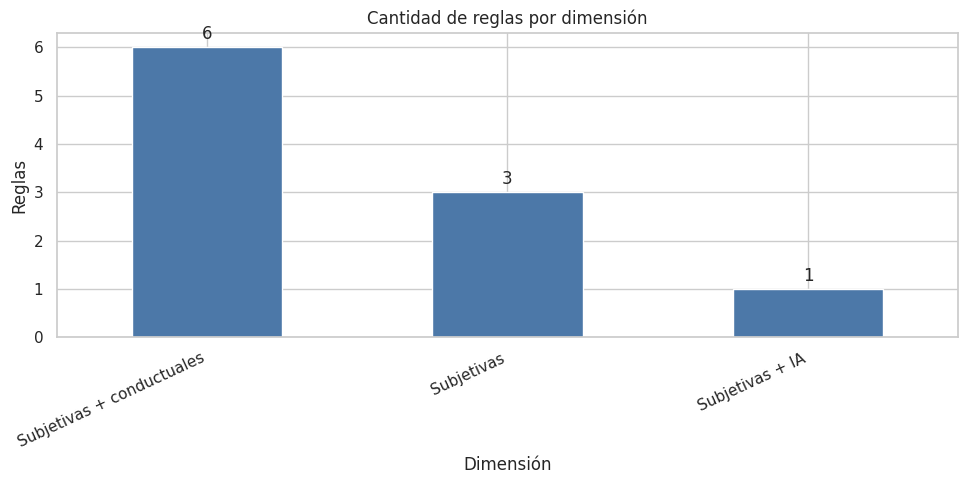

In [16]:
grupo_subjetivas = {
    "stress_level",
    "motivation_score",
    "placement_anxiety_score",
    "interview_anxiety_score",
    "career_clarity_score",
    "resume_confidence_score",
}

grupo_ia = {
    "daily_ai_tool_usage_hrs",
    "uses_ai_for_assignments",
    "ai_dependency_score",
    "ai_replaces_own_thinking_score",
    "fear_of_job_loss_to_ai",
    "primary_ai_tools_used",
}

grupo_conductuales_contextuales = {
    "sleep_hours",
    "daily_study_hours",
    "self_learning_hours_per_week",
    "social_media_hrs_per_day",
    "weekly_job_application_count",
    "skill_development_courses_taken",
    "internship_experience",
    "seeks_career_counseling",
    "gender",
    "degree_type",
    "stream",
    "year_of_study",
    "college_tier",
    "urban_or_rural",
}


def classify_rule_dimension(antecedents):
    variables = {str(item).split("=", 1)[0] for item in antecedents}
    dimensions = []

    if variables & grupo_subjetivas:
        dimensions.append("subjetivas/emocionales")
    if variables & grupo_ia:
        dimensions.append("IA")
    if variables & grupo_conductuales_contextuales:
        dimensions.append("conductuales/contextuales")

    return " + ".join(dimensions) if dimensions else "otra"


final_rules = final_rules.copy()
final_rules["dimension"] = final_rules["antecedents"].apply(classify_rule_dimension)

display(
    final_rules[
        ["dimension", "antecedente", "support", "confidence", "lift", "score"]
    ].round(3)
)

if final_rules.empty:
    display(Markdown("No hay reglas finales para graficar con los umbrales definidos."))
else:
    dimension_counts = final_rules["dimension"].value_counts()
    dimension_short_labels = {
        "subjetivas/emocionales": "Subjetivas",
        "IA": "IA",
        "conductuales/contextuales": "Conductuales",
        "subjetivas/emocionales + IA": "Subjetivas + IA",
        "subjetivas/emocionales + conductuales/contextuales": "Subjetivas + conductuales",
        "IA + conductuales/contextuales": "IA + conductuales",
        "subjetivas/emocionales + IA + conductuales/contextuales": "Subjetivas + IA + conductuales",
        "otra": "Otra",
    }
    dimension_counts_plot = dimension_counts.rename(index=dimension_short_labels)

    plt.figure(figsize=(10, 5))
    ax = dimension_counts_plot.plot(kind="bar", color="#4C78A8")
    ax.bar_label(ax.containers[0], padding=3)
    plt.title("Cantidad de reglas por dimensión")
    plt.xlabel("Dimensión")
    plt.ylabel("Reglas")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## 9.6 Tabla final para conclusión

La siguiente tabla resume las reglas finales seleccionadas para apoyar la conclusión del análisis. Estas reglas no representan causalidad, sino combinaciones de condiciones que presentan una asociación fuerte con `burnout_cat=alto`.

In [17]:
final_rules_summary = final_rules.copy()
final_rules_summary["interpretacion"] = final_rules_summary.apply(
    lambda row: (
        f"Cuando aparece {row['antecedente']}, la proporción de casos con burnout alto "
        f"es {row['confidence']:.1%}, con un lift de {row['lift']:.2f}."
    ),
    axis=1,
)

display(
    final_rules_summary[
        ["dimension", "antecedente", "support", "confidence", "lift", "interpretacion"]
    ].round(3)
)

,dimension,antecedente,support,confidence,lift,interpretacion
0,subjetivas/emocionales,motivation_score=bajo + stress_level=alto,0.078,0.855,2.491,"Cuando aparece motivation_score=bajo + stress_level=alto, la proporción de casos con burnout alto es 85.5%, con un l..."
1,subjetivas/emocionales + conductuales/contextuales,seeks_career_counseling=si + stress_level=alto,0.074,0.837,2.436,"Cuando aparece seeks_career_counseling=si + stress_level=alto, la proporción de casos con burnout alto es 83.7%, con..."
2,subjetivas/emocionales + conductuales/contextuales,motivation_score=bajo + seeks_career_counseling=si + stress_level=alto,0.048,0.911,2.652,"Cuando aparece motivation_score=bajo + seeks_career_counseling=si + stress_level=alto, la proporción de casos con bu..."
3,subjetivas/emocionales + conductuales/contextuales,motivation_score=bajo + seeks_career_counseling=si,0.119,0.724,2.109,"Cuando aparece motivation_score=bajo + seeks_career_counseling=si, la proporción de casos con burnout alto es 72.4%,..."
4,subjetivas/emocionales + IA,fear_of_job_loss_to_ai=alto + stress_level=alto,0.106,0.742,2.160,"Cuando aparece fear_of_job_loss_to_ai=alto + stress_level=alto, la proporción de casos con burnout alto es 74.2%, co..."
5,subjetivas/emocionales + conductuales/contextuales,interview_anxiety_score=alto + motivation_score=bajo + seeks_career_counseling=si,0.090,0.762,2.219,"Cuando aparece interview_anxiety_score=alto + motivation_score=bajo + seeks_career_counseling=si, la proporción de c..."
6,subjetivas/emocionales,interview_anxiety_score=alto + stress_level=alto,0.103,0.736,2.143,"Cuando aparece interview_anxiety_score=alto + stress_level=alto, la proporción de casos con burnout alto es 73.6%, c..."
7,subjetivas/emocionales,placement_anxiety_score=alto + stress_level=alto,0.103,0.731,2.128,"Cuando aparece placement_anxiety_score=alto + stress_level=alto, la proporción de casos con burnout alto es 73.1%, c..."
8,subjetivas/emocionales + conductuales/contextuales,stress_level=alto + weekly_job_application_count=alto,0.108,0.721,2.099,"Cuando aparece stress_level=alto + weekly_job_application_count=alto, la proporción de casos con burnout alto es 72...."
9,subjetivas/emocionales + conductuales/contextuales,motivation_score=bajo + placement_anxiety_score=alto + seeks_career_counseling=si,0.087,0.761,2.216,"Cuando aparece motivation_score=bajo + placement_anxiety_score=alto + seeks_career_counseling=si, la proporción de c..."


## 9.7 Reglas priorizadas que incluyen variables de IA

Aunque el ranking final balanceado selecciona solo un subconjunto reducido de reglas, también es importante revisar por separado las reglas que contienen variables asociadas al uso o percepción de IA. Esto permite analizar si la IA aparece como parte de combinaciones asociadas a burnout alto, aunque no todas esas reglas queden dentro del top final por score.

Esta revisión es exploratoria y debe interpretarse como asociación, no causalidad.

In [18]:
ia_variables = {
    "daily_ai_tool_usage_hrs",
    "uses_ai_for_assignments",
    "ai_dependency_score",
    "ai_replaces_own_thinking_score",
    "fear_of_job_loss_to_ai",
    "primary_ai_tools_used",
}

ia_rules = non_redundant_rules[
    non_redundant_rules["antecedents"].apply(
        lambda antecedents: any(
            str(item).split("=", 1)[0] in ia_variables
            for item in antecedents
        )
    )
].copy()

ia_rules = ia_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False,
    ignore_index=True,
)

print(f"Reglas no redundantes que incluyen variables de IA: {len(ia_rules):,}")

display(
    ia_rules[
        ["antecedente", "consecuente", "support", "confidence", "lift", "n_antecedentes"]
    ].head(10).round(3)
)

Reglas no redundantes que incluyen variables de IA: 38


,antecedente,consecuente,support,confidence,lift,n_antecedentes
0,ai_dependency_score=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.033,0.951,2.771,3
1,daily_ai_tool_usage_hrs=alto + motivation_score=bajo + stress_level=alto,burnout_cat=alto,0.035,0.923,2.687,3
2,ai_replaces_own_thinking_score=medio + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.038,0.913,2.658,3
3,daily_ai_tool_usage_hrs=alto + seeks_career_counseling=si + stress_level=alto,burnout_cat=alto,0.032,0.907,2.642,3
4,ai_dependency_score=alto + stress_level=alto,burnout_cat=alto,0.048,0.871,2.537,2
5,ai_dependency_score=alto + motivation_score=bajo + seeks_career_counseling=si,burnout_cat=alto,0.054,0.831,2.420,3
6,ai_replaces_own_thinking_score=medio + stress_level=alto,burnout_cat=alto,0.062,0.824,2.401,2
7,daily_ai_tool_usage_hrs=alto + motivation_score=bajo + seeks_career_counseling=si,burnout_cat=alto,0.053,0.805,2.343,3
8,daily_ai_tool_usage_hrs=alto + stress_level=alto,burnout_cat=alto,0.055,0.798,2.325,2
9,motivation_score=bajo + placement_anxiety_score=alto + uses_ai_for_assignments=frequently,burnout_cat=alto,0.032,0.798,2.323,3


La tabla permite observar si las variables relacionadas con IA aparecen asociadas a burnout alto principalmente de forma aislada o combinadas con factores subjetivos, conductuales o contextuales. Para la conclusión, estas reglas deben compararse con las reglas finales generales y no interpretarse como evidencia causal.

## 9.8 Interpretación preliminar de las reglas priorizadas

Después de aplicar los filtros de priorización, reducción de redundancia y selección de la mejor regla por grupo de variables, el análisis se concentra en un conjunto reducido de reglas finales.

Estas reglas permitirán responder:

1. Qué combinaciones presentan mayor asociación con `burnout_cat=alto`.
2. Qué variables aparecen de forma más consistente en las reglas finales.
3. Si las variables relacionadas con IA aparecen junto a variables subjetivas, conductuales o contextuales.
4. Si `sleep_hours=bajo` aumenta su asociación con burnout alto cuando se combina con estrés, ansiedad, dependencia de IA u otros factores.
5. Qué reglas tienen un lift suficientemente alto como para ser consideradas asociaciones fuertes o muy fuertes.

La conclusión final debe construirse a partir de la tabla `final_rules_summary`, evitando afirmar causalidad.

### Top 10 reglas por lift

La visualización compara reglas asociadas a burnout alto. La posición horizontal representa el lift, el color representa la confianza y el tamaño del punto representa el soporte. Así se puede observar qué reglas combinan asociación fuerte, alta confianza y presencia suficiente en el dataset.

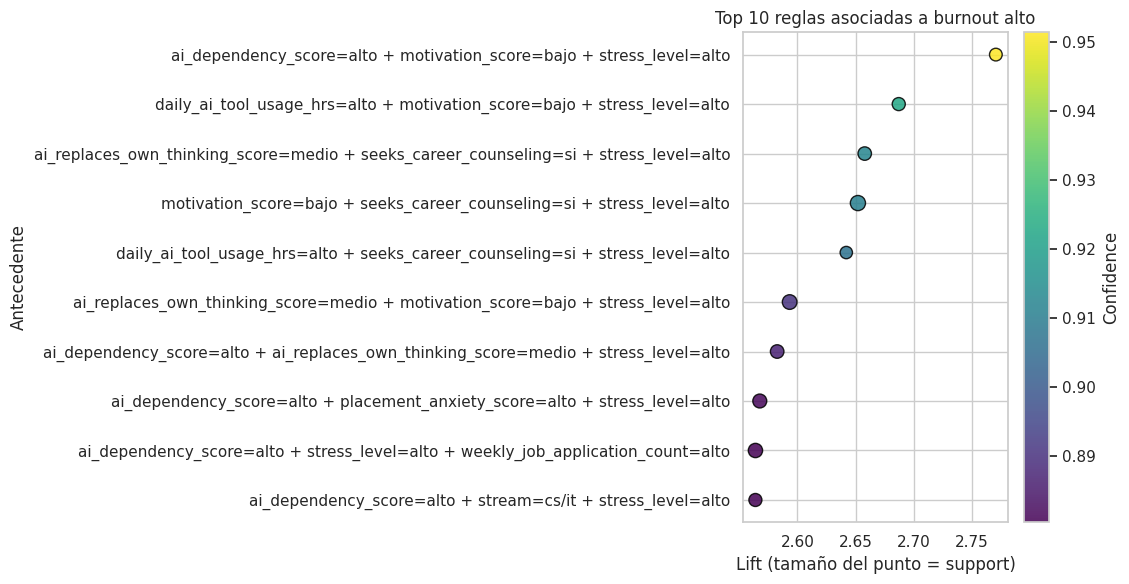

In [19]:
top_rules = relevant_rules.head(10).sort_values("lift", ascending=True)

if top_rules.empty:
    display(Markdown("No hay reglas que cumplan todos los filtros definidos."))
else:
    plt.figure(figsize=(11, 6))
    points = plt.scatter(
        top_rules["lift"],
        top_rules["antecedente"],
        s=top_rules["support"] * 2500,
        c=top_rules["confidence"],
        cmap="viridis",
        edgecolor="black",
        alpha=0.85,
    )
    plt.colorbar(points, label="Confidence")
    plt.title("Top 10 reglas asociadas a burnout alto")
    plt.xlabel("Lift (tamaño del punto = support)")
    plt.ylabel("Antecedente")
    plt.tight_layout()
    plt.show()

## 10. Variables más frecuentes en reglas exploratorias

Esta sección cuenta qué variables aparecen con mayor frecuencia en las reglas exploratorias filtradas inicialmente. Esto no debe interpretarse como importancia causal ni como selección final de variables. La frecuencia solo indica presencia repetida dentro del conjunto amplio de reglas relevantes.

Para la conclusión final se utilizará principalmente la tabla `final_rules_summary`, que contiene reglas priorizadas, no redundantes y seleccionadas mediante un ranking balanceado.

,variable,apariciones_en_reglas,porcentaje_reglas
0,motivation_score,440,27.92
1,seeks_career_counseling,374,23.73
2,stress_level,317,20.11
3,ai_dependency_score,307,19.48
4,placement_anxiety_score,277,17.58
5,interview_anxiety_score,263,16.69
6,fear_of_job_loss_to_ai,248,15.74
7,ai_replaces_own_thinking_score,227,14.40
8,daily_ai_tool_usage_hrs,219,13.90
9,career_clarity_score,201,12.75


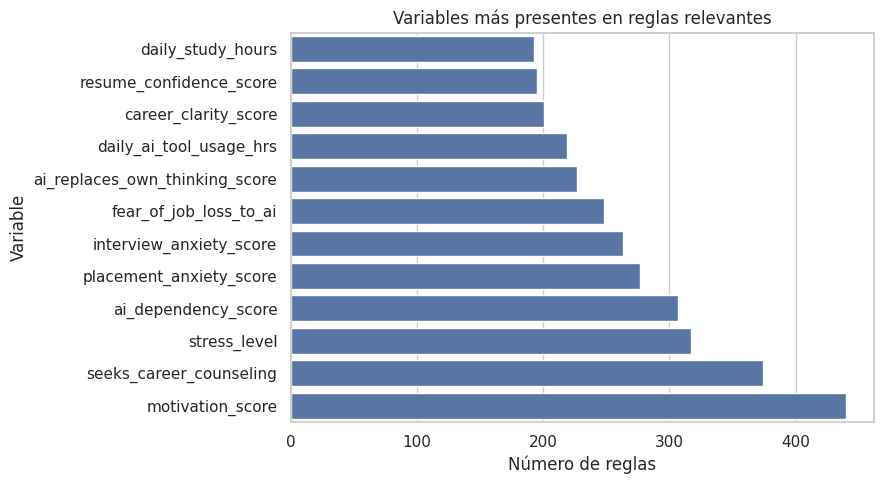

In [20]:
variable_counter = Counter()
for antecedent in relevant_rules["antecedents"]:
    variable_counter.update(item.split("=", 1)[0] for item in antecedent)

variable_frequency = pd.DataFrame(
    variable_counter.most_common(),
    columns=["variable", "apariciones_en_reglas"],
)
if not variable_frequency.empty:
    variable_frequency["porcentaje_reglas"] = (
        variable_frequency["apariciones_en_reglas"] / len(relevant_rules) * 100
    ).round(2)

display(variable_frequency.head(15))

if not variable_frequency.empty:
    plot_frequency = variable_frequency.head(12).sort_values(
        "apariciones_en_reglas"
    )
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=plot_frequency,
        x="apariciones_en_reglas",
        y="variable",
        color="#4C72B0",
    )
    plt.title("Variables más presentes en reglas relevantes")
    plt.xlabel("Número de reglas")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

## 10.1 Variables más frecuentes en reglas finales

Además del conteo exploratorio, se revisan las variables presentes en las reglas finales. Este conteo es más útil para la conclusión, porque considera únicamente las reglas priorizadas, no redundantes y seleccionadas por el ranking balanceado.

,variable,apariciones_en_reglas_finales
0,stress_level,7
1,motivation_score,5
2,seeks_career_counseling,5
3,interview_anxiety_score,2
4,placement_anxiety_score,2
5,fear_of_job_loss_to_ai,1
6,weekly_job_application_count,1


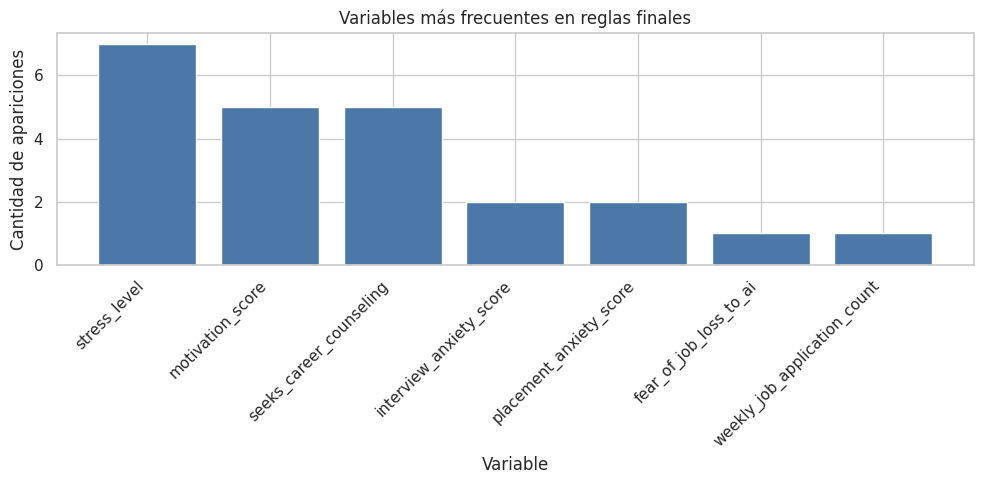

In [21]:
final_variable_counter = Counter()

for antecedent in final_rules["antecedents"]:
    final_variable_counter.update(
        str(item).split("=", 1)[0] for item in antecedent
    )

final_variable_frequency = pd.DataFrame(
    final_variable_counter.most_common(),
    columns=["variable", "apariciones_en_reglas_finales"],
)

display(final_variable_frequency)

if final_variable_frequency.empty:
    display(Markdown("No hay reglas finales para calcular frecuencias."))
else:
    plt.figure(figsize=(10, 5))
    plt.bar(
        final_variable_frequency["variable"],
        final_variable_frequency["apariciones_en_reglas_finales"],
        color="#4C78A8",
    )
    plt.title("Variables más frecuentes en reglas finales")
    plt.xlabel("Variable")
    plt.ylabel("Cantidad de apariciones")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 11. Comparación explícita de combinaciones con sueño bajo

Las cinco combinaciones solicitadas se calculan directamente sobre la matriz de
transacciones, incluso si FP-Growth no las devuelve por el umbral de soporte. Esto
permite distinguir entre una regla ausente por baja frecuencia y una regla sin
asociación positiva.

In [22]:
def calculate_manual_rule(matrix, antecedent, consequent=TARGET_ITEM):
    missing_items = [
        item for item in [*antecedent, consequent] if item not in matrix.columns
    ]
    if missing_items:
        return {
            "antecedente": format_itemset(antecedent),
            "disponible": False,
            "support": np.nan,
            "confidence": np.nan,
            "lift": np.nan,
            "casos_antecedente": 0,
            "casos_regla": 0,
        }

    antecedent_mask = matrix[list(antecedent)].all(axis=1)
    consequent_mask = matrix[consequent]
    joint_mask = antecedent_mask & consequent_mask

    antecedent_support = antecedent_mask.mean()
    consequent_support = consequent_mask.mean()
    support = joint_mask.mean()
    confidence = support / antecedent_support if antecedent_support else np.nan
    lift = confidence / consequent_support if consequent_support else np.nan

    return {
        "antecedente": format_itemset(antecedent),
        "disponible": True,
        "support": support,
        "confidence": confidence,
        "lift": lift,
        "casos_antecedente": int(antecedent_mask.sum()),
        "casos_regla": int(joint_mask.sum()),
    }


sleep_combinations = [
    ["sleep_hours=bajo", "motivation_score=alto"],
    ["sleep_hours=bajo", "fear_of_job_loss_to_ai=alto"],
    ["sleep_hours=bajo", "stress_level=alto"],
    ["sleep_hours=bajo", "ai_dependency_score=alto"],
    ["sleep_hours=bajo", "placement_anxiety_score=alto"],
]

sleep_rule_comparison = pd.DataFrame(
    [
        calculate_manual_rule(transaction_matrix, antecedent)
        for antecedent in sleep_combinations
    ]
).sort_values(["lift", "confidence"], ascending=False, ignore_index=True)

display(
    sleep_rule_comparison.style.format(
        {"support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.3f}"}
    )
)

,antecedente,disponible,support,confidence,lift,casos_antecedente,casos_regla
0,sleep_hours=bajo + stress_level=alto,True,0.037,0.714,2.080,574,410
1,ai_dependency_score=alto + sleep_hours=bajo,True,0.028,0.636,1.852,486,309
2,placement_anxiety_score=alto + sleep_hours=bajo,True,0.047,0.576,1.677,917,528
3,fear_of_job_loss_to_ai=alto + sleep_hours=bajo,True,0.055,0.531,1.547,1156,614
4,motivation_score=alto + sleep_hours=bajo,True,0.003,0.141,0.410,220,31


### Sueño bajo por sí solo

La regla simple sirve como línea base para evaluar si agregar otra condición mejora
la asociación observada con burnout alto.

In [23]:
sleep_only = pd.DataFrame(
    [calculate_manual_rule(transaction_matrix, ["sleep_hours=bajo"])]
)
display(
    sleep_only.style.format(
        {"support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.3f}"}
    )
)

,antecedente,disponible,support,confidence,lift,casos_antecedente,casos_regla
0,sleep_hours=bajo,True,0.069,0.454,1.323,1684,765


## 12. Relación entre support, confidence y lift

Cada punto representa una regla relevante. Esta vista ayuda a evitar que un lift
alto oculte una frecuencia marginal: el tamaño del punto vuelve a representar el
support.

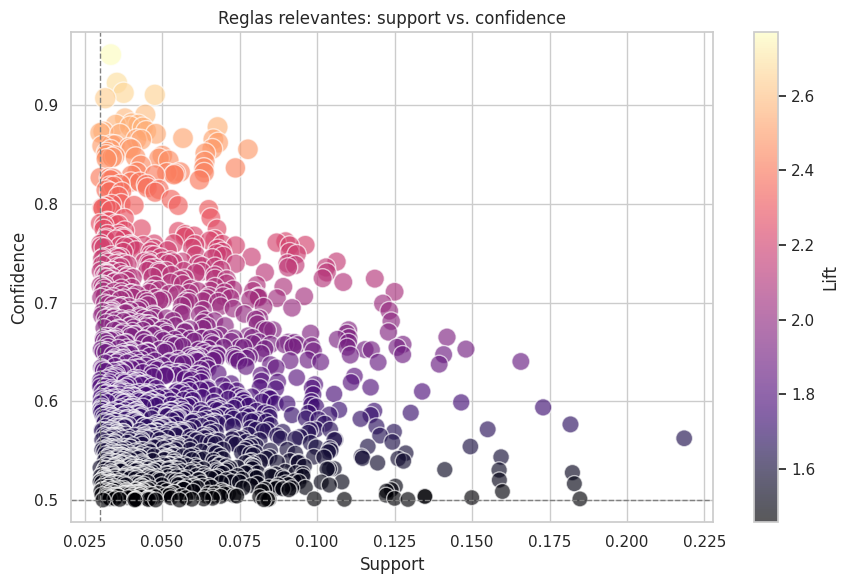

In [24]:
if relevant_rules.empty:
    display(Markdown("No hay reglas relevantes para construir el gráfico."))
else:
    plt.figure(figsize=(9, 6))
    scatter = plt.scatter(
        relevant_rules["support"],
        relevant_rules["confidence"],
        s=relevant_rules["lift"] * 90,
        c=relevant_rules["lift"],
        cmap="magma",
        alpha=0.65,
        edgecolor="white",
    )
    plt.colorbar(scatter, label="Lift")
    plt.axhline(MIN_CONFIDENCE, color="gray", linestyle="--", linewidth=1)
    plt.axvline(MIN_SUPPORT, color="gray", linestyle="--", linewidth=1)
    plt.title("Reglas relevantes: support vs. confidence")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.tight_layout()
    plt.show()

### Nota sobre `seeks_career_counseling`

La variable `seeks_career_counseling=si` debe interpretarse con cautela. Su presencia en reglas asociadas a burnout alto no significa que buscar orientación cause burnout. Una interpretación más razonable es que estudiantes con mayor presión, incertidumbre o malestar académico-laboral podrían tender a buscar orientación profesional. Por lo tanto, esta variable puede funcionar como señal asociada al estado del estudiante, no necesariamente como factor causal.

## 13. Interpretación de resultados

La siguiente síntesis se genera a partir de las métricas calculadas. Responde qué
combinaciones destacan, qué variables se repiten, cómo aparecen las variables de IA
y si el sueño bajo necesita combinarse con otros factores.

In [25]:
def metric_phrase(value):
    return "no disponible" if pd.isna(value) else f"{value:.2f}"


def select_best_final_rule(rules_summary):
    if rules_summary.empty:
        return None
    if "score" in rules_summary.columns and rules_summary["score"].notna().any():
        return rules_summary.loc[rules_summary["score"].idxmax()]
    return rules_summary.iloc[0]


best_final_rule = select_best_final_rule(final_rules_summary)

if best_final_rule is None:
    interpretation = (
        "El análisis exploratorio produjo reglas en `relevant_rules`, pero después de "
        "la priorización y reducción de redundancia no quedaron reglas en "
        "`final_rules_summary` para sustentar la conclusión. Esto no demuestra ausencia "
        "de asociaciones; indica que ninguna regla cumplió todos los criterios finales."
    )
else:
    top_variables = ", ".join(
        final_variable_frequency.head(5)["variable"].astype(str)
    )
    if not top_variables:
        top_variables = "no disponibles"

    ai_rule_count = len(ia_rules)
    best_sleep_pair = (
        sleep_rule_comparison.iloc[0]
        if not sleep_rule_comparison.empty
        else None
    )
    sleep_simple = sleep_only.iloc[0] if not sleep_only.empty else None

    best_sleep_text = (
        f"**{best_sleep_pair['antecedente']}**, con lift "
        f"**{metric_phrase(best_sleep_pair['lift'])}** y confidence "
        f"**{metric_phrase(best_sleep_pair['confidence'])}**"
        if best_sleep_pair is not None
        else "no está disponible con las categorías evaluadas"
    )
    sleep_simple_lift = (
        metric_phrase(sleep_simple["lift"])
        if sleep_simple is not None
        else "no disponible"
    )

    score_text = (
        f" y score {best_final_rule['score']:.3f}"
        if "score" in best_final_rule.index and pd.notna(best_final_rule["score"])
        else ""
    )

    interpretation = f"""
- `relevant_rules` contiene las reglas del análisis exploratorio amplio. Para esta
  conclusión se utiliza `final_rules_summary`, que reúne reglas priorizadas, no
  redundantes y seleccionadas mediante el ranking balanceado.
- La regla final mejor posicionada es **{best_final_rule['antecedente']} -> {TARGET_ITEM}**,
  con support {best_final_rule['support']:.3f}, confidence
  {best_final_rule['confidence']:.3f}, lift {best_final_rule['lift']:.3f}{score_text}.
  Esta combinación presenta una asociación con burnout alto, no una relación causal.
- Las variables que más se repiten en las reglas finales son: **{top_variables}**.
  Su frecuencia indica recurrencia dentro del conjunto final, no importancia causal.
- Se identificaron **{ai_rule_count} reglas no redundantes con variables de IA** en
  `ia_rules`. Estas reglas muestran que variables de uso o percepción de IA aparecen
  junto a otras condiciones asociadas a burnout alto, sin demostrar que la IA lo cause.
- La regla simple `sleep_hours=bajo` presenta lift **{sleep_simple_lift}**. Entre las
  combinaciones evaluadas con sueño bajo, la asociación más alta corresponde a
  {best_sleep_text}.
- La comparación de sueño debe interpretarse respecto de la frecuencia base de burnout
  alto: lift mayor que 1 indica asociación positiva, cercano a 1 indica poca diferencia
  y menor que 1 indica asociación negativa. Ninguno de estos valores demuestra causalidad.
"""

display(Markdown(interpretation))


- `relevant_rules` contiene las reglas del análisis exploratorio amplio. Para esta
  conclusión se utiliza `final_rules_summary`, que reúne reglas priorizadas, no
  redundantes y seleccionadas mediante el ranking balanceado.
- La regla final mejor posicionada es **motivation_score=bajo + stress_level=alto -> burnout_cat=alto**,
  con support 0.078, confidence
  0.855, lift 2.491 y score 0.594.
  Esta combinación presenta una asociación con burnout alto, no una relación causal.
- Las variables que más se repiten en las reglas finales son: **stress_level, motivation_score, seeks_career_counseling, interview_anxiety_score, placement_anxiety_score**.
  Su frecuencia indica recurrencia dentro del conjunto final, no importancia causal.
- Se identificaron **38 reglas no redundantes con variables de IA** en
  `ia_rules`. Estas reglas muestran que variables de uso o percepción de IA aparecen
  junto a otras condiciones asociadas a burnout alto, sin demostrar que la IA lo cause.
- La regla simple `sleep_hours=bajo` presenta lift **1.32**. Entre las
  combinaciones evaluadas con sueño bajo, la asociación más alta corresponde a
  **sleep_hours=bajo + stress_level=alto**, con lift **2.08** y confidence **0.71**.
- La comparación de sueño debe interpretarse respecto de la frecuencia base de burnout
  alto: lift mayor que 1 indica asociación positiva, cercano a 1 indica poca diferencia
  y menor que 1 indica asociación negativa. Ninguno de estos valores demuestra causalidad.


## 14. Exportación de resultados

Las tablas se guardan como artefactos secundarios para facilitar su uso en informes.
Las tablas visibles en el notebook siguen siendo la evidencia principal del análisis.

In [26]:
itemsets_export = frequent_itemsets.copy()
itemsets_export["itemsets"] = itemsets_export["itemsets"].map(format_itemset)

target_rules_export = target_rules.copy()
target_rules_export["antecedente"] = target_rules_export["antecedents"].map(
    format_itemset
)
target_rules_export["consecuente"] = TARGET_ITEM
target_rules_export = target_rules_export[
    [
        "antecedente",
        "consecuente",
        "antecedent support",
        "consequent support",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction",
        "zhangs_metric",
        "n_antecedentes",
    ]
]

relevant_export = relevant_rules[
    [
        "antecedente",
        "consecuente",
        "support",
        "confidence",
        "lift",
        "n_antecedentes",
    ]
]

exports = {
    "itemsets_frecuentes_reglas_asociacion.csv": itemsets_export,
    "reglas_burnout_alto.csv": target_rules_export,
    "reglas_burnout_alto_relevantes.csv": relevant_export,
    "frecuencia_variables_reglas_asociacion.csv": variable_frequency,
    "comparacion_reglas_sueno_bajo.csv": sleep_rule_comparison,
    "reglas_priorizadas_burnout_alto.csv": priority_rules[
        ["antecedente", "consecuente", "support", "confidence", "lift", "n_antecedentes"]
    ],
    "reglas_no_redundantes_burnout_alto.csv": non_redundant_rules[
        ["antecedente", "consecuente", "support", "confidence", "lift", "n_antecedentes"]
    ],
    "mejor_regla_por_grupo_variables.csv": best_by_group[
        ["grupo_variables", "antecedente", "consecuente", "support", "confidence", "lift"]
    ],
    "reglas_finales_burnout_alto.csv": final_rules_summary[
        ["dimension", "antecedente", "support", "confidence", "lift", "interpretacion"]
    ],
    "frecuencia_variables_reglas_finales.csv": final_variable_frequency,
    "reglas_ia_burnout_alto.csv": ia_rules[
        ["antecedente", "consecuente", "support", "confidence", "lift", "n_antecedentes"]
    ],
}

for filename, table in exports.items():
    path = OUTPUT_TABLES / filename
    table.to_csv(path, index=False)
    print(f"{filename}: {len(table):,} filas")

itemsets_frecuentes_reglas_asociacion.csv: 63,725 filas
reglas_burnout_alto.csv: 4,286 filas
reglas_burnout_alto_relevantes.csv: 1,576 filas
frecuencia_variables_reglas_asociacion.csv: 20 filas
comparacion_reglas_sueno_bajo.csv: 5 filas
reglas_priorizadas_burnout_alto.csv: 282 filas
reglas_no_redundantes_burnout_alto.csv: 65 filas
mejor_regla_por_grupo_variables.csv: 61 filas
reglas_finales_burnout_alto.csv: 10 filas
frecuencia_variables_reglas_finales.csv: 7 filas
reglas_ia_burnout_alto.csv: 38 filas


## 15. Conclusión

El análisis mediante reglas de asociación permitió identificar combinaciones de variables asociadas a `burnout_cat=alto`, complementando el análisis exploratorio previo basado en relaciones individuales. A diferencia de una correlación simple, este enfoque permitió observar patrones compuestos entre factores subjetivos, conductuales, contextuales y variables relacionadas con el uso o percepción de IA.

Después de generar las reglas exploratorias, se aplicó una etapa adicional de priorización para evitar interpretar un número excesivo de reglas. Para ello, se conservaron reglas con soporte suficiente, confianza alta, lift fuerte y un número limitado de antecedentes. Además, se redujo la redundancia entre reglas y se seleccionó un conjunto final de reglas más interpretables. Esta decisión permitió pasar desde un análisis amplio a una lectura más clara y defendible de los patrones asociados al burnout alto.

Los resultados muestran que `stress_level=alto` fue la variable más consistente dentro de las reglas finales. Esta variable apareció frecuentemente combinada con `motivation_score=bajo`, `seeks_career_counseling=si`, `interview_anxiety_score=alto`, `placement_anxiety_score=alto` y `fear_of_job_loss_to_ai=alto`. Por lo tanto, el burnout alto no parece estar asociado a una única condición aislada, sino a la acumulación de factores relacionados con estrés, baja motivación, ansiedad académica-laboral y preocupación frente al futuro profesional.

Una regla especialmente relevante fue la combinación entre `motivation_score=bajo` y `stress_level=alto`, que presentó una alta confianza y un lift superior a 2. Esto indica que, dentro del dataset, los estudiantes que presentan simultáneamente bajo nivel de motivación y alto nivel de estrés tienen una proporción de burnout alto considerablemente mayor que la probabilidad base de burnout alto observada en la muestra.

También se observó que `seeks_career_counseling=si` aparece en varias reglas finales. Esta variable debe interpretarse con cautela: no significa que buscar orientación cause burnout, sino que puede actuar como una señal asociada a estudiantes que ya presentan mayor presión, incertidumbre o malestar académico-laboral. En este sentido, la búsqueda de orientación podría reflejar una respuesta frente a una situación de mayor desgaste.

Respecto a las variables relacionadas con IA, el análisis mostró que sí aparecen en reglas asociadas a burnout alto, especialmente cuando se combinan con variables subjetivas como `stress_level=alto` o `motivation_score=bajo`. En particular, reglas que incluyen `ai_dependency_score=alto`, `daily_ai_tool_usage_hrs=alto` o `fear_of_job_loss_to_ai=alto` presentan lift elevado cuando aparecen junto a estrés alto o baja motivación. Esto sugiere que las variables de IA no necesariamente explican el burnout por sí solas, pero pueden formar parte de perfiles de mayor riesgo cuando se combinan con presión emocional o académica.

La comparación específica con `sleep_hours=bajo` también permitió matizar la interpretación. Dormir pocas horas por sí solo presentó una asociación moderada con burnout alto. Sin embargo, cuando `sleep_hours=bajo` se combinó con `stress_level=alto`, `ai_dependency_score=alto` o `placement_anxiety_score=alto`, la asociación aumentó considerablemente. En cambio, la combinación `sleep_hours=bajo + motivation_score=alto` presentó un lift menor a 1, lo que indica una asociación negativa con burnout alto dentro del dataset. Esto refuerza la idea de que el sueño bajo no debe interpretarse de forma aislada, sino en conjunto con otros factores.

En síntesis, las reglas de asociación muestran que el burnout alto se asocia principalmente con combinaciones de estrés alto, baja motivación, ansiedad académica-laboral, búsqueda de orientación y algunas variables vinculadas al uso o percepción de IA. Estos resultados no permiten afirmar causalidad, pero sí entregan evidencia útil para identificar patrones frecuentes asociados a burnout alto. En una etapa posterior, estas variables y combinaciones podrían servir como base para construir o mejorar modelos predictivos, incorporando no solo variables individuales, sino también interacciones entre factores subjetivos, conductuales y tecnológicos.

## 16. Uso del modelo

En reglas de asociación "usar el modelo" significa aplicar las reglas finales a
estudiantes concretos. Cada estudiante se representa con el **mismo conjunto de
atributos discretizados** que se utilizó para generar las reglas. Una regla final
*se activa* para un estudiante cuando **todos los ítems de su antecedente** están
presentes en sus atributos; en ese caso se le asocia el consecuente
`burnout_cat=alto` junto con la confianza y el lift de la regla.

A continuación se muestran tres perfiles de estudiantes reales del dataset,
seleccionados de forma automática para ilustrar distintos casos de uso:

- **Perfil A:** estudiante con la mayor cantidad de reglas de riesgo activadas.
- **Perfil B:** estudiante donde se activa al menos una regla que incluye variables de IA.
- **Perfil C:** estudiante de contraste, donde no se activa ninguna regla priorizada.


In [ ]:
# === 16. Uso del modelo: aplicar las reglas finales a estudiantes concretos ===

# 1) Ítems (atributos discretizados) de cada estudiante, excluyendo el objetivo.
attribute_columns = [c for c in discretized.columns if c != "burnout_cat"]


def student_items(row):
    return {f"{col}={row[col]}" for col in attribute_columns}


student_item_sets = {
    idx: student_items(discretized.loc[idx]) for idx in discretized.index
}

# 2) Reglas finales en una estructura cómoda para evaluar la activación.
final_rule_records = []
for _, rule in final_rules.iterrows():
    final_rule_records.append(
        {
            "antecedente": rule["antecedente"],
            "items": set(rule["antecedents"]),
            "confidence": float(rule["confidence"]),
            "lift": float(rule["lift"]),
            "dimension": rule.get("dimension", "sin clasificar"),
        }
    )


def activated_rules(items):
    """Reglas finales cuyo antecedente está contenido en los atributos del estudiante."""
    activadas = [r for r in final_rule_records if r["items"].issubset(items)]
    return sorted(activadas, key=lambda r: (r["lift"], r["confidence"]), reverse=True)


if not final_rule_records:
    display(Markdown(
        "No hay reglas finales disponibles con los umbrales actuales, por lo que no "
        "es posible ilustrar el uso del modelo. Revise los filtros de la sección 9."
    ))
else:
    # 3) Reglas activadas por estudiante (para elegir perfiles ilustrativos).
    activation_counts = {
        idx: len(activated_rules(items)) for idx, items in student_item_sets.items()
    }
    activation_series = pd.Series(activation_counts).sort_values(ascending=False)

    ia_variables = {
        "daily_ai_tool_usage_hrs",
        "uses_ai_for_assignments",
        "ai_dependency_score",
        "ai_replaces_own_thinking_score",
        "fear_of_job_loss_to_ai",
        "primary_ai_tools_used",
    }

    def rule_has_ia(rule):
        return any(item.split("=", 1)[0] in ia_variables for item in rule["items"])

    # Perfil A: estudiante con MÁS reglas activadas (mayor acumulación de factores).
    perfil_alto_riesgo = activation_series.index[0]

    # Perfil B: estudiante donde se activa al menos una regla que incluye IA.
    perfil_ia = None
    for idx in activation_series.index:
        if idx == perfil_alto_riesgo:
            continue
        if any(rule_has_ia(r) for r in activated_rules(student_item_sets[idx])):
            perfil_ia = idx
            break
    if perfil_ia is None:  # respaldo: segundo estudiante con más activaciones
        perfil_ia = activation_series.index[min(1, len(activation_series) - 1)]

    # Perfil C: estudiante SIN reglas activadas (contraste: no se marca como riesgo).
    sin_activacion = activation_series[activation_series == 0]
    perfil_contraste = (
        sin_activacion.index[0] if not sin_activacion.empty else activation_series.index[-1]
    )

    perfiles = {
        "Perfil A — acumulación de factores": perfil_alto_riesgo,
        "Perfil B — combinación con uso de IA": perfil_ia,
        "Perfil C — contraste (bajo riesgo)": perfil_contraste,
    }

    # Variables que aparecen en alguna regla final (atributos relevantes a mostrar).
    rule_vars = {
        item.split("=", 1)[0] for r in final_rule_records for item in r["items"]
    }

    def describe_profile(nombre, idx):
        items = student_item_sets[idx]
        activadas = activated_rules(items)
        burnout_real = df_analysis.loc[idx, "burnout_cat"]
        atributos = {
            col: discretized.loc[idx, col]
            for col in attribute_columns
            if col in rule_vars
        }

        lines = [f"### {nombre} (estudiante #{idx})", ""]
        lines.append(f"- **Burnout real (solo referencia):** `burnout_cat={burnout_real}`")
        lines.append(
            "- **Atributos discretizados relevantes:** "
            + ", ".join(f"`{k}={v}`" for k, v in atributos.items())
        )
        lines.append("")
        if activadas:
            lines.append(f"**Reglas finales activadas ({len(activadas)}):**")
            lines.append("")
            lines.append("| Antecedente | Consecuente | Confianza | Lift | Dimensión |")
            lines.append("|---|---|---:|---:|---|")
            for r in activadas:
                lines.append(
                    f"| {r['antecedente']} | burnout_cat=alto | "
                    f"{r['confidence']:.1%} | {r['lift']:.2f} | {r['dimension']} |"
                )
            top = activadas[0]
            lines.append("")
            lines.append(
                f"**Interpretación:** este estudiante cae en el patrón "
                f"*{top['antecedente']}*. Dentro del dataset, el "
                f"{top['confidence']:.1%} de los estudiantes con ese patrón presentan "
                f"burnout alto (lift {top['lift']:.2f}, es decir ~{top['lift']:.1f}× la "
                f"frecuencia base de burnout alto). Es un perfil que el sistema marcaría "
                f"como de **riesgo de burnout alto** y candidato a apoyo temprano."
            )
        else:
            lines.append(
                "**Reglas finales activadas: ninguna.** Ningún patrón priorizado de "
                "riesgo aparece completo en sus atributos, por lo que el sistema **no** "
                "lo marcaría como riesgo alto. Sirve de contraste: las reglas discriminan "
                "y no etiquetan a todos los estudiantes por igual."
            )
        return "\n".join(lines)

    for nombre, idx in perfiles.items():
        display(Markdown(describe_profile(nombre, idx)))
        display(Markdown("---"))


**Utilidad práctica.** Estas reglas convierten el análisis en una herramienta de
**detección temprana**: a partir de atributos que una institución ya recopila
(nivel de estrés, motivación, ansiedad académica-laboral, hábitos de sueño y uso de
IA), permiten señalar de forma transparente qué estudiantes presentan combinaciones
de factores asociadas a burnout alto. A diferencia de un modelo de caja negra, cada
señal viene acompañada de la regla que la justifica (antecedente, confianza y lift),
lo que facilita priorizar focos de apoyo y comunicar el porqué de cada alerta. No se
trata de un diagnóstico individual ni de una relación causal, sino de un criterio
interpretable para orientar acompañamiento y prevención.


## 17. Estrategia de validación (por qué no hay train-test split)

Las reglas de asociación son una técnica **no supervisada**: no se entrena un modelo
para predecir una etiqueta a partir de ejemplos, sino que se describen patrones de
co-ocurrencia presentes en todo el conjunto de transacciones. Por eso **no se aplica
una división train/test clásica**: no existe una métrica de generalización (como
accuracy en datos no vistos) que un split permita estimar; todas las transacciones se
usan para medir soporte, confianza y lift de los patrones.

En lugar de un split, la validez de las reglas se controla evitando que sean
**espurias**, mediante los criterios aplicados en este notebook:

- **Soporte mínimo (`support >= 0.03`):** descarta patrones que aparecen en muy pocos
  estudiantes y que, por tanto, no son generalizables dentro del dataset.
- **Confianza mínima (`confidence >= 0.50` en exploración, `>= 0.70` en priorización):**
  exige que una proporción alta de quienes cumplen el antecedente presenten burnout alto.
- **Lift > 1 (`> 1.30` en exploración, `>= 2.00` en priorización):** garantiza que la
  asociación sea **positiva** y muy por encima de la frecuencia base de burnout alto;
  un lift cercano o menor a 1 indica asociación nula o negativa y se descarta.
- **Reducción de redundancia:** se eliminan reglas anidadas que no mejoran el lift
  respecto de una regla más simple, evitando contar el mismo patrón varias veces.
- **Número limitado de antecedentes (2 a 3 condiciones):** mantiene las reglas
  interpretables y evita combinaciones tan específicas que solo describen el ruido.
- **Ranking balanceado (`lift * confidence * sqrt(support)`):** prioriza reglas que son
  fuertes y frecuentes a la vez, no patrones de lift alto pero soporte marginal.

**Limitación de validez externa.** El dataset es **sintético** (generado mediante
*latent trait modeling* con ruido controlado), por lo que las reglas describen la
estructura simulada de los datos y **no deben extrapolarse** a una población estudiantil
real sin una validación posterior sobre datos primarios. Las reglas son, además,
asociaciones y no relaciones causales.
